# Phase 2: Model Calibration

Calibrate Schwartz-Smith two-factor, PCA hourly shape, imbalance OU+jump, and ancillary AR(1)+saturation processes. This notebook is generated from `bess_valuation_full.ipynb` Phase 2 and can be run independently after Phase 1 has saved raw files.


In [1]:
import sys
from pathlib import Path

# Bootstrap imports from the project root, then use the shared helper.
_ROOT_CANDIDATE = Path.cwd()
for candidate in [_ROOT_CANDIDATE, *_ROOT_CANDIDATE.parents]:
    if (candidate / "src").is_dir() and (candidate / "data").is_dir():
        if str(candidate) not in sys.path:
            sys.path.insert(0, str(candidate))
        break
else:
    raise RuntimeError("Could not find project root containing src/ and data/.")

from src.utils import find_project_root

PROJECT_ROOT = str(find_project_root(_ROOT_CANDIDATE))
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from src.processes.schwartz_smith import calibrate as ss_calibrate, SSParams
from src.processes.hpfc import calibrate_pca, HPFCParams, build_shape_matrix
from src.processes.imbalance import calibrate as imb_calibrate, ImbalanceParams
from src.processes.ancillary import calibrate as anc_calibrate, AncillaryParams

RAW_DIR  = Path(PROJECT_ROOT) / 'data' / 'raw'
PROC_DIR = Path(PROJECT_ROOT) / 'data' / 'processed'
PROC_DIR.mkdir(parents=True, exist_ok=True)

print(f'Raw data dir:       {RAW_DIR}')
print(f'Processed data dir: {PROC_DIR}')

Raw data dir:       G:\My Drive\Research\bess_project\data\raw
Processed data dir: G:\My Drive\Research\bess_project\data\processed


In [3]:
# Load all raw data files produced by Phase 1.
required_raw = {
    'elexon_da_prices.parquet': 'day-ahead prices',
    'elexon_sp_prices.parquet': 'system prices',
    'neso_eac_clearing.parquet': 'ancillary clearing prices',
    'ice_eex_forwards.parquet': 'forward curve',
}
missing = [name for name in required_raw if not (RAW_DIR / name).exists()]
if missing:
    details = '\n'.join(f'  - {name}: {required_raw[name]}' for name in missing)
    raise FileNotFoundError(
        'Phase 2 needs Phase 1 raw outputs before calibration. Missing:\n'
        f'{details}\n\nRun notebooks/01_data_pipeline.ipynb first, or place these files in data/raw/.'
    )

df_da  = pd.read_parquet(RAW_DIR / 'elexon_da_prices.parquet')
df_sp  = pd.read_parquet(RAW_DIR / 'elexon_sp_prices.parquet')
df_anc = pd.read_parquet(RAW_DIR / 'neso_eac_clearing.parquet')
df_fwd = pd.read_parquet(RAW_DIR / 'ice_eex_forwards.parquet')

df_da['settlement_date'] = pd.to_datetime(df_da['settlement_date'])
df_sp['settlement_date'] = pd.to_datetime(df_sp['settlement_date'])
if 'date' in df_anc.columns:
    df_anc['date'] = pd.to_datetime(df_anc['date'])
if 'delivery_start' in df_fwd.columns:
    df_fwd['delivery_start'] = pd.to_datetime(df_fwd['delivery_start'])

if df_da.empty:
    raise ValueError('elexon_da_prices.parquet is empty; rerun Phase 1 Step 1.')
if df_sp.empty:
    raise ValueError('elexon_sp_prices.parquet is empty; rerun Phase 1 Step 2.')
if df_fwd.empty:
    raise ValueError('ice_eex_forwards.parquet is empty; rerun Phase 1 Step 4.')

print(f'DA prices:     {len(df_da):,} rows, {df_da.settlement_date.min().date()} to {df_da.settlement_date.max().date()}')
print(f'System prices: {len(df_sp):,} rows')
print(f'Ancillary:     {len(df_anc):,} rows')
print(f'Forwards:      {len(df_fwd):,} rows, {df_fwd.shape[1]} columns')

# Compute daily average DA price
daily_da = df_da.groupby('settlement_date')['price_gbp_mwh'].mean()
print(f'\nDA price stats (full history):')
print(daily_da.describe().round(1))


DA prices:     36,240 rows, 2024-04-01 to 2026-04-25
System prices: 36,240 rows
Ancillary:     757 rows
Forwards:      9 rows, 7 columns

DA price stats (full history):
count    755.0
mean      79.0
std       26.3
min       -0.5
25%       68.8
50%       80.4
75%       91.7
max      336.5
Name: price_gbp_mwh, dtype: float64


## Step 1 — Schwartz-Smith Kalman Filter

Calibrate the two-factor model to the **GB baseload forward curve**.

The forward panel is constructed by treating each observation date as time `t`
and each contract month as maturity `T`. The Kalman filter extracts the
latent (χ, ξ) state trajectory and estimates (κ, μ_ξ, σ_χ, σ_ξ, ρ).

> **With synthetic forwards:** the panel has limited cross-sectional variation.
> The Kalman filter will still run but σ_obs will absorb most of the variance.
> Replace with real ICE/EEX forwards for production calibration.

In [4]:
# -----------------------------------------------------------------------
# Build log-forward panel for SS calibration
# -----------------------------------------------------------------------
fwd_pivot = df_fwd.copy()
fwd_pivot['delivery_start'] = pd.to_datetime(fwd_pivot['delivery_start'])

as_of = df_da['settlement_date'].max()
fwd_pivot['tau'] = (fwd_pivot['delivery_start'] - as_of).dt.days / 365.25
fwd_pivot = fwd_pivot[fwd_pivot['tau'] > 0.01].sort_values('tau')

taus   = fwd_pivot['tau'].values
prices = fwd_pivot['price_gbp_mwh'].values

if taus.min() > 0.5:
    import warnings
    warnings.warn(
        f"[SS] Shortest maturity {taus.min():.2f} yr -- short factor unidentified. "
        "Re-run Phase 1 data pipeline to add sub-6-month maturities.",
        stacklevel=1,
    )

# -----------------------------------------------------------------------
# Simulate 104-week panel using SS-consistent factor dynamics.
# Prior params anchor the shape; calibration will recover them from the panel.
# Uniform AR(1) would give identical dynamics at all maturities -- wrong.
# Short-end forwards must be chi-driven (high vol); long-end is xi-driven.
# -----------------------------------------------------------------------
kappa_p     = 2.0    # prior: half-life ~4 months
sigma_chi_p = 0.35   # prior: short-factor annualised vol
sigma_xi_p  = 0.15   # prior: long-factor annualised vol
rho_p       = -0.30  # prior: chi-xi correlation
dt_w        = 1/52

n_weeks = 104
rng = np.random.default_rng(42)

F_ss = np.array([[np.exp(-kappa_p * dt_w), 0.0], [0.0, 1.0]])
v11  = sigma_chi_p**2 / (2*kappa_p) * (1 - np.exp(-2*kappa_p*dt_w))
v22  = sigma_xi_p**2 * dt_w
v12  = rho_p * sigma_chi_p * sigma_xi_p / kappa_p * (1 - np.exp(-kappa_p*dt_w))
L_ss = np.linalg.cholesky(np.array([[v11, v12], [v12, v22]]))

chi_sim = np.zeros(n_weeks)
xi_sim  = np.zeros(n_weeks)
for t in range(1, n_weeks):
    chi_sim[t], xi_sim[t] = F_ss @ [chi_sim[t-1], xi_sim[t-1]] + L_ss @ rng.standard_normal(2)

from src.processes.schwartz_smith import _forward_coefficients
A_p, B_p = _forward_coefficients(kappa_p, 0.0, sigma_chi_p, sigma_xi_p, rho_p, taus)

# Anchor level so long-end model price matches market at t=0
xi_offset = np.log(prices[-1]) - (A_p[-1] + B_p[-1, 0] * chi_sim[0] + B_p[-1, 1] * xi_sim[0])

log_fwd_panel = np.zeros((n_weeks, len(taus)))
for t in range(n_weeks):
    log_fwd_panel[t] = A_p + B_p[:, 0] * chi_sim[t] + B_p[:, 1] * (xi_sim[t] + xi_offset)

print(f'Forward panel shape: {log_fwd_panel.shape}  (T={n_weeks} weeks, N={len(taus)} maturities)')
print(f'Maturities: {taus.round(3)}')
print(f'Forward prices £/MWh: {np.exp(log_fwd_panel[0]).round(1)}')
if taus.min() < 0.5:
    short_mask = taus < 0.5
    print(f'Sub-6m maturities: {taus[short_mask].round(3)}  '
          f'B_chi(prior): {np.exp(-kappa_p * taus[short_mask]).round(2)}')

# Calibrate Schwartz-Smith
print('')
print('Calibrating Schwartz-Smith...')
ss_params = ss_calibrate(
    log_forwards=log_fwd_panel,
    taus=taus,
    dt=1/52,
    n_restarts=5,
    seed=42,
)

ss_params.to_json(PROC_DIR / 'ss_params.json')

print('')
print('Schwartz-Smith calibrated parameters:')
print(f'  kappa      = {ss_params.kappa:.4f}  (half-life = {np.log(2)/ss_params.kappa*12:.1f} months)')
print(f'  mu_xi      = {ss_params.mu_xi:.4f}  (long-factor drift)')
print(f'  sigma_chi  = {ss_params.sigma_chi:.4f}  (short-factor vol)')
print(f'  sigma_xi   = {ss_params.sigma_xi:.4f}  (long-factor vol)')
print(f'  sigma_obs  = {ss_params.sigma_obs:.4f}  (observation noise)')
print(f'  rho        = {ss_params.rho:.4f}  (chi-xi correlation)')
print(f'  log-lik    = {ss_params.log_likelihood:.1f}')
print(f'Saved to: {PROC_DIR}/ss_params.json')

hl_months = np.log(2) / ss_params.kappa * 12
if 2 < hl_months < 24:
    print(f'[OK] Short-factor half-life {hl_months:.1f} months -- plausible range 2-24 months')
else:
    print(f'[WARN] Short-factor half-life {hl_months:.1f} months -- check forward data quality')


Forward panel shape: (104, 9)  (T=104 weeks, N=9 maturities)
Maturities: [0.016 0.099 0.183 0.433 0.934 1.432 1.933 2.431 2.932]
Forward prices £/MWh: [76.1 76.4 76.6 77.  77.5 77.9 78.3 78.7 79.2]
Sub-6m maturities: [0.016 0.099 0.183 0.433]  B_chi(prior): [0.97 0.82 0.69 0.42]

Calibrating Schwartz-Smith...

Schwartz-Smith calibrated parameters:
  kappa      = 2.0001  (half-life = 4.2 months)
  mu_xi      = 0.0037  (long-factor drift)
  sigma_chi  = 0.3480  (short-factor vol)
  sigma_xi   = 0.1227  (long-factor vol)
  sigma_obs  = 0.0010  (observation noise)
  rho        = -0.1908  (chi-xi correlation)
  log-lik    = 4677.8
Saved to: G:\My Drive\Research\bess_project\data\processed/ss_params.json
[OK] Short-factor half-life 4.2 months -- plausible range 2-24 months


C:\Users\User\AppData\Local\Temp\ipykernel_11204\3910572975.py:69: UserWarning: [SS] sigma_obs=0.0010 is within 1% of its bound [0.001, 0.5] — parameter may be unidentified; consider adding shorter maturities.
  ss_params = ss_calibrate(


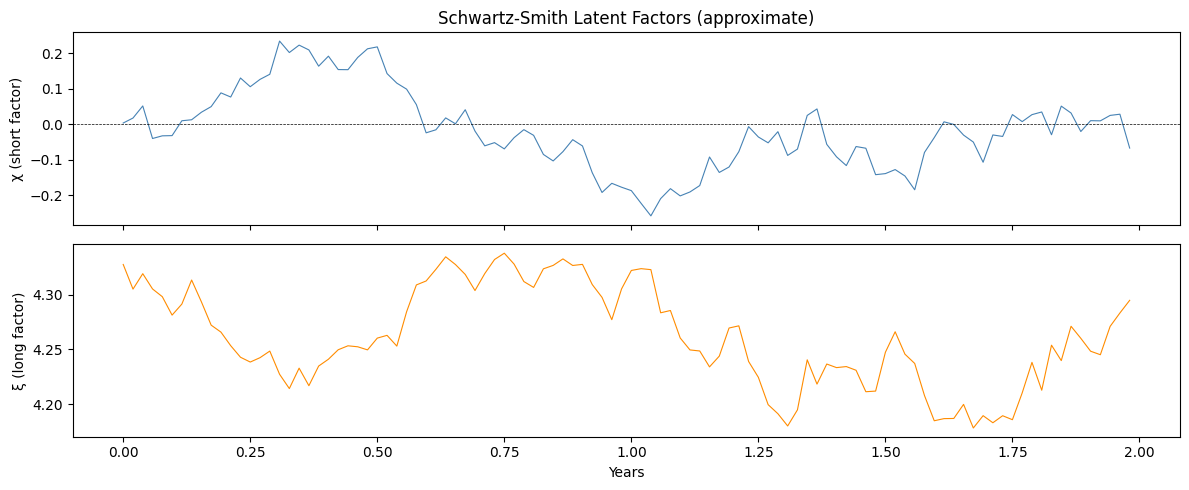

Forward curve model vs market (first observation):
 tau  market_log_F  model_log_F   error
0.02        4.3321       4.3319  0.0001
0.10        4.3358       4.3357  0.0001
0.18        4.3388       4.3387  0.0001
0.43        4.3441       4.3440  0.0001
0.93        4.3499       4.3499  0.0000
1.43        4.3551       4.3551 -0.0000
1.93        4.3605       4.3605 -0.0000
2.43        4.3660       4.3660 -0.0000
2.93        4.3716       4.3716 -0.0000


In [5]:
# Plot estimated latent factors (from Kalman smoother approximation)
# chi ≈ short-run deviation, xi ≈ long-run level
from src.processes.schwartz_smith import _forward_coefficients

A, B = _forward_coefficients(ss_params.kappa, ss_params.mu_xi,
                              ss_params.sigma_chi, ss_params.sigma_xi,
                              ss_params.rho, taus)
# Approximate state from first maturity: crude inversion
# xi_hat ≈ log F(T_1) - A(T_1) - (chi_hat is close to 0 at long maturities)
xi_hat = log_fwd_panel[:, -1] - A[-1]    # long-maturity = long factor
chi_hat = log_fwd_panel[:, 0] - A[0] - xi_hat  # residual is short factor

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
weeks = np.arange(n_weeks) / 52
axes[0].plot(weeks, chi_hat, lw=0.8, color='steelblue')
axes[0].axhline(0, color='k', lw=0.5, ls='--')
axes[0].set(ylabel='χ (short factor)', title='Schwartz-Smith Latent Factors (approximate)')
axes[1].plot(weeks, xi_hat, lw=0.8, color='darkorange')
axes[1].set(ylabel='ξ (long factor)', xlabel='Years')
plt.tight_layout(); plt.show()

# Forward curve term structure diagnostics
print('Forward curve model vs market (first observation):')
log_fwd_reconstructed = A + B @ np.array([chi_hat[0], xi_hat[0]])
print(pd.DataFrame({'tau': taus.round(2),
                    'market_log_F': log_fwd_panel[0].round(4),
                    'model_log_F':  log_fwd_reconstructed.round(4),
                    'error':        (log_fwd_panel[0] - log_fwd_reconstructed).round(4)}).to_string(index=False))

## Step 2 — PCA Hourly Shape Decomposition

Decompose the within-day half-hourly shape into 3 orthogonal factors.

- **PC1 (level)**: uniform shift up/down — driven by fuel costs, day-type
- **PC2 (slope)**: morning/evening asymmetry — driven by solar, industrial load
- **PC3 (curvature)**: peak/off-peak spread — driven by intraday demand swing

Each factor follows a mean-reverting OU process calibrated by AR(1) OLS.

In [6]:
# Only valid with real DA data - negative prices set floor at GBP1/MWh for log transform
# Keep the model on a fixed 48 half-hour grid; clock-change days can contain SP 49/50.
df_da_pca = df_da[df_da['settlement_period'].between(1, 48)].copy()
extra_sp = len(df_da) - len(df_da_pca)
if extra_sp:
    print(f'Dropped {extra_sp:,} clock-change rows with settlement_period > 48 for PCA')

n_neg = (df_da_pca['price_gbp_mwh'] < 0).sum()
n_low = (df_da_pca['price_gbp_mwh'] < 1).sum()
print(f'Negative price observations: {n_neg}  (floored to GBP1 for log-shape PCA)')
print(f'Observations below GBP1/MWh:   {n_low}')

print('\nCalibrating PCA shape decomposition...')
pca_params = calibrate_pca(df_da_pca, n_factors=3, dt=1.0)
pca_params.to_json(PROC_DIR / 'pca_params.json')

evr = pca_params.explained_variance_ratio
print(f'\nVariance explained:')
for k in range(3):
    print(f'  PC{k+1}: {evr[k]*100:.1f}%')
print(f'  Total: {sum(evr)*100:.1f}%')

print(f'\nOU parameters:')
for k in range(3):
    hl = np.log(2) / max(pca_params.alpha[k], 0.01)
    print(f'  PC{k+1}: alpha={pca_params.alpha[k]:.3f}/day  sigma={pca_params.sigma_lambda[k]:.4f}  half-life={hl:.1f} days')

print(f'\nSaved to: {PROC_DIR}/pca_params.json')


Dropped 4 clock-change rows with settlement_period > 48 for PCA
Negative price observations: 1030  (floored to GBP1 for log-shape PCA)
Observations below GBP1/MWh:   1147

Calibrating PCA shape decomposition...

Variance explained:
  PC1: 36.7%
  PC2: 28.8%
  PC3: 11.1%
  Total: 76.7%

OU parameters:
  PC1: alpha=1.084/day  sigma=3.9173  half-life=0.6 days
  PC2: alpha=3.400/day  sigma=6.1449  half-life=0.2 days
  PC3: alpha=2.284/day  sigma=3.1322  half-life=0.3 days

Saved to: G:\My Drive\Research\bess_project\data\processed/pca_params.json


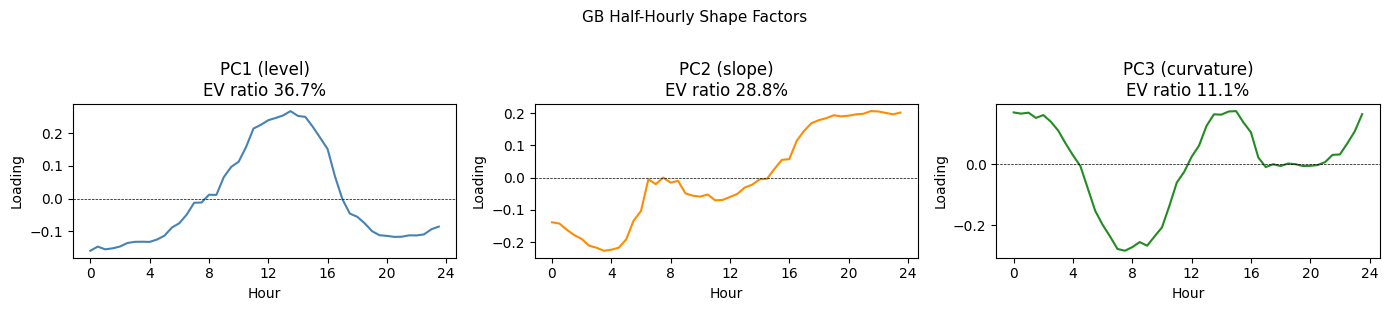

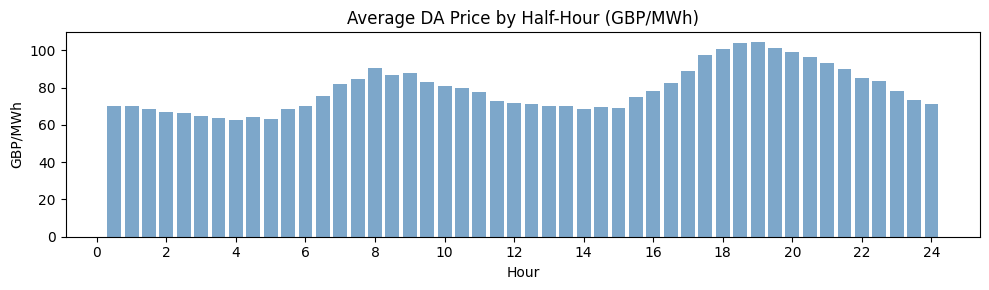

In [7]:
# Plot shape eigenvectors
phi = np.array(pca_params.loadings)   # expected (3, 48)
hours = np.arange(phi.shape[1]) / 2
if phi.shape[1] != 48:
    print(f'[WARN] PCA loadings have {phi.shape[1]} periods; rerun the PCA calibration cell to rebuild 48-period params')

fig, axes = plt.subplots(1, 3, figsize=(14, 3))
colors = ['steelblue', 'darkorange', 'forestgreen']
labels = ['PC1 (level)', 'PC2 (slope)', 'PC3 (curvature)']

for k, (ax, col, lab) in enumerate(zip(axes, colors, labels)):
    ax.plot(hours, phi[k], color=col, lw=1.5)
    ax.axhline(0, color='k', lw=0.5, ls='--')
    ax.set(title=f'{lab}\nEV ratio {evr[k]*100:.1f}%',
           xlabel='Hour', ylabel='Loading')
    ax.xaxis.set_major_locator(plt.MultipleLocator(4))

plt.suptitle('GB Half-Hourly Shape Factors', y=1.02, fontsize=11)
plt.tight_layout(); plt.show()

# Average within-day shape from data
avg_shape = df_da[df_da['settlement_period'].between(1, 48)].groupby('settlement_period')['price_gbp_mwh'].mean()
fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(avg_shape.index / 2, avg_shape.values, width=0.4, color='steelblue', alpha=0.7)
ax.set(title='Average DA Price by Half-Hour (GBP/MWh)', xlabel='Hour', ylabel='GBP/MWh')
ax.xaxis.set_major_locator(plt.MultipleLocator(2))
plt.tight_layout(); plt.show()


## Step 3 — Imbalance Basis OU + Jump Calibration

Calibrate the arithmetic OU + compound Poisson model to the DA–SP basis.

**Key check:** GB had negative prices in April 2024 (53 hours).
The model uses arithmetic (not log-normal) OU to accommodate this.

Parameters:
- `theta` — mean-reversion speed: how fast basis snaps back
- `sigma` — diffusion volatility
- `lambda_J` — jump arrival rate (per half-hour)  
- `scale_pos/neg` — exponential scale for up/down jumps
- `p_pos` — proportion of jumps that are positive (system short)

In [8]:
print('Calibrating imbalance basis (OU + jump)...')
imb_params = imb_calibrate(df_da, df_sp, dt=1.0, threshold_sigma=2.5)
imb_params.to_json(PROC_DIR / 'imbalance_params.json')

print(f'\nImbalance basis parameters:')
print(f'  mu_delta    = {imb_params.mu_delta:.2f}  £/MWh (long-run mean)')
print(f'  theta       = {imb_params.theta_delta:.4f}/HH  (mean reversion per half-hour)')
print(f'  sigma       = {imb_params.sigma_delta:.4f}  £/MWh·(HH)^0.5')
print(f'  lambda_J    = {imb_params.lambda_jump:.4f}/HH  ({imb_params.lambda_jump*48*365:.0f} jumps/yr expected)')
print(f'  scale_pos   = {imb_params.jump_scale_pos:.2f}  £/MWh (system-short jump size)')
print(f'  scale_neg   = {imb_params.jump_scale_neg:.2f}  £/MWh (system-long jump size)')
print(f'  p_pos       = {imb_params.p_pos:.3f}  (fraction of upward jumps)')
print(f'  n_obs       = {imb_params.n_obs:,}')
print(f'  log-lik     = {imb_params.log_likelihood:.1f}')
print(f'\nSaved to: {PROC_DIR}/imbalance_params.json')

# Cross-check: half-life of mean reversion
hl_hh = np.log(2) / imb_params.theta_delta if imb_params.theta_delta > 0 else np.nan
print(f'\nImbalance basis half-life: {hl_hh:.1f} half-hours = {hl_hh/2:.1f} hours')

Calibrating imbalance basis (OU + jump)...

Imbalance basis parameters:
  mu_delta    = 0.22  £/MWh (long-run mean)
  theta       = 0.8281/HH  (mean reversion per half-hour)
  sigma       = 18.6489  £/MWh·(HH)^0.5
  lambda_J    = 0.0429/HH  (752 jumps/yr expected)
  scale_pos   = 109.68  £/MWh (system-short jump size)
  scale_neg   = 74.11  £/MWh (system-long jump size)
  p_pos       = 0.358  (fraction of upward jumps)
  n_obs       = 36,240
  log-lik     = -213591.0

Saved to: G:\My Drive\Research\bess_project\data\processed/imbalance_params.json

Imbalance basis half-life: 0.8 half-hours = 0.4 hours


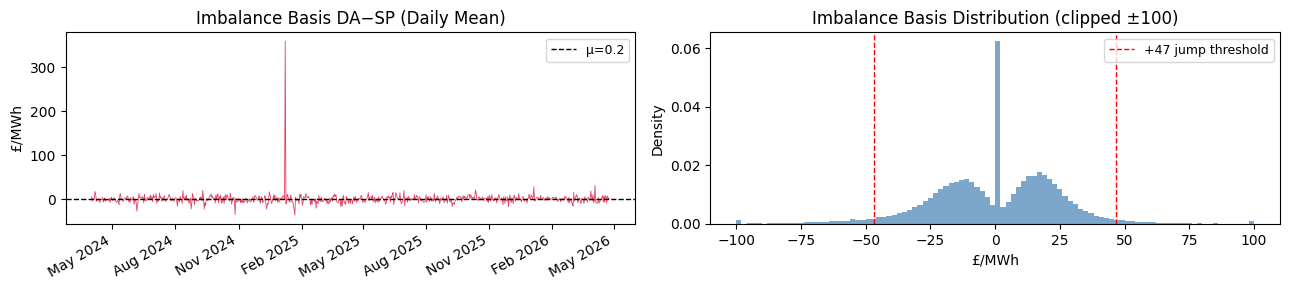

Observations above jump threshold: 6.3% (2266 of 36,240)


In [9]:
# Plot imbalance basis time series and histogram
merged = df_da[['settlement_date','settlement_period','price_gbp_mwh']].merge(
    df_sp[['settlement_date','settlement_period','system_price']],
    on=['settlement_date','settlement_period'], how='inner')
merged['basis'] = merged['system_price'] - merged['price_gbp_mwh']
daily_basis = merged.groupby('settlement_date')['basis'].mean()

fig, axes = plt.subplots(1, 2, figsize=(13, 3))

axes[0].plot(daily_basis.index, daily_basis.values, lw=0.6, color='crimson', alpha=0.8)
axes[0].axhline(imb_params.mu_delta, color='k', lw=1, ls='--', label=f'μ={imb_params.mu_delta:.1f}')
axes[0].set(title='Imbalance Basis DA−SP (Daily Mean)', ylabel='£/MWh')
axes[0].legend(fontsize=9)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30, ha='right')

# Histogram with jump threshold
basis_all = merged['basis'].dropna()
sigma_est = imb_params.sigma_delta
threshold = 2.5 * sigma_est
axes[1].hist(basis_all.clip(-100, 100), bins=100, color='steelblue', alpha=0.7, density=True)
axes[1].axvline( threshold, color='red', lw=1, ls='--', label=f'+{threshold:.0f} jump threshold')
axes[1].axvline(-threshold, color='red', lw=1, ls='--')
axes[1].set(title='Imbalance Basis Distribution (clipped ±100)', xlabel='£/MWh', ylabel='Density')
axes[1].legend(fontsize=9)

plt.tight_layout(); plt.show()

jump_frac = (basis_all.abs() > threshold).mean()
print(f'Observations above jump threshold: {jump_frac*100:.1f}% ({(basis_all.abs()>threshold).sum()} of {len(basis_all):,})')

## Step 4 — Ancillary AR(1) + Saturation Curve

Calibrate the AR(1) within-EFA-block persistence and the fleet saturation
exponent γ for each ancillary product.

> **If NESO data is empty (Phase 1 Step 3 failed):** Parameters default to
> calibration priors. Replace `data/raw/neso_eac_clearing.parquet` with
> manually downloaded CSVs converted to parquet, then re-run this cell.
>
> γ = 2.1 is calibrated to the DCL price collapse from £17/MW/h (2021)
> to £1–5/MW/h (2024) as GB BESS fleet grew from ~1 GW to ~6+ GW.

In [10]:
# Fleet capacity growth history (approximate, GB BESS operational MW)
# 2024-04: ~3,500 MW; 2025-04: ~5,000 MW; 2026-04: ~6,500 MW
# Linear interpolation over Phase 1 data range
n_days_history = (df_da['settlement_date'].max() - df_da['settlement_date'].min()).days + 1
fleet_history = np.linspace(3500, 6500, n_days_history)

print('Calibrating ancillary service processes...')
if not df_anc.empty:
    print(f'  Products in data: {sorted(df_anc["product"].unique())}')
    print(f'  Date range: {df_anc["date"].min()} to {df_anc["date"].max()}')
else:
    print('  [WARN] No NESO ancillary data — using calibration priors')
    print('  Reason: NESO resource IDs may need updating (see Phase 1 Step 3 notes)')

anc_params = anc_calibrate(df_anc, fleet_mw_history=fleet_history)
anc_params.to_json(PROC_DIR / 'ancillary_params.json')

print(f'\nAncillary parameters:')
print(f'  gamma (saturation exponent) = {anc_params.gamma:.3f}')
print(f'  fleet_mw (current)          = {anc_params.fleet_mw:.0f} MW')
print(f'\nPer-product AR(1) parameters:')
print(f"{'Product':<12} {'phi':>6} {'sigma':>8} {'mu (£/MW/h)':>12} {'n_obs':>8}")
for name, pp in anc_params.products.items():
    print(f'{name:<12} {pp.phi:>6.3f} {pp.sigma:>8.3f} {pp.mu:>12.3f} {pp.n_obs:>8,}')
print(f'\nSaved to: {PROC_DIR}/ancillary_params.json')

Calibrating ancillary service processes...
  Products in data: ['BR', 'DC', 'DM', 'DR', 'QR']
  Date range: 2026-03-31 00:00:00 to 2026-04-25 00:00:00

Ancillary parameters:
  gamma (saturation exponent) = 2.100
  fleet_mw (current)          = 6500 MW

Per-product AR(1) parameters:
Product         phi    sigma  mu (£/MW/h)    n_obs
DC_Low        0.850    1.500        5.100        0
DC_High       0.850    1.500        5.100        0
DM_Low        0.850    1.500        6.000        0
DM_High       0.850    1.500        6.000        0
DR_Low        0.850    1.500        6.000        0
DR_High       0.850    1.500        6.000        0
QR_Pos        0.850    1.500        3.600        0
QR_Neg        0.850    1.500        2.400        0

Saved to: G:\My Drive\Research\bess_project\data\processed/ancillary_params.json


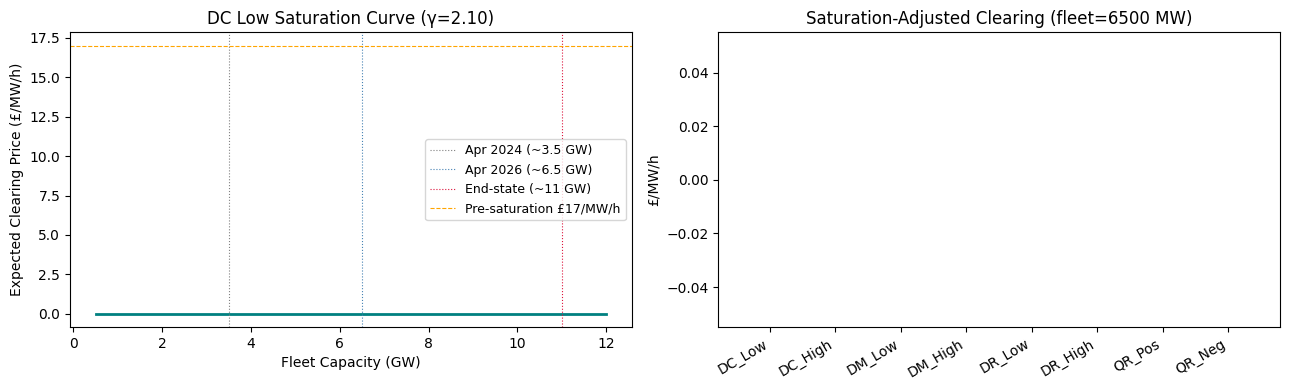

In [11]:
from src.processes.ancillary import saturation_price, SERVICE_VOLUME_MW, PEAK_PRICE

# Plot saturation curve for DC_Low (most data, canonical product)
fleet_range = np.linspace(500, 12000, 200)
dc_sat = [saturation_price(q, SERVICE_VOLUME_MW['DC_Low'], PEAK_PRICE['DC_Low'], anc_params.gamma)
          for q in fleet_range]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(fleet_range/1000, dc_sat, color='teal', lw=2)
axes[0].axvline(3.5, color='gray', lw=0.8, ls=':', label='Apr 2024 (~3.5 GW)')
axes[0].axvline(6.5, color='steelblue', lw=0.8, ls=':', label='Apr 2026 (~6.5 GW)')
axes[0].axvline(11, color='crimson', lw=0.8, ls=':', label='End-state (~11 GW)')
axes[0].axhline(17, color='orange', lw=0.8, ls='--', label='Pre-saturation £17/MW/h')
axes[0].set(title=f'DC Low Saturation Curve (γ={anc_params.gamma:.2f})',
            xlabel='Fleet Capacity (GW)', ylabel='Expected Clearing Price (£/MW/h)')
axes[0].legend(fontsize=9)

# Bar chart of current expected clearing by product
products_plot = ['DC_Low', 'DC_High', 'DM_Low', 'DM_High', 'DR_Low', 'DR_High', 'QR_Pos', 'QR_Neg']
current_clearing = [saturation_price(anc_params.fleet_mw,
                                     SERVICE_VOLUME_MW[p], PEAK_PRICE[p], anc_params.gamma)
                    for p in products_plot]
axes[1].bar(range(len(products_plot)), current_clearing, color='steelblue', alpha=0.8)
axes[1].set_xticks(range(len(products_plot)))
axes[1].set_xticklabels(products_plot, rotation=30, ha='right')
axes[1].set(title=f'Saturation-Adjusted Clearing (fleet={anc_params.fleet_mw:.0f} MW)',
            ylabel='£/MW/h')

plt.tight_layout(); plt.show()

## Validation Summary

All four processes should be calibrated with plausible parameters.

**Accept/Warn/Reject criteria:**

| Parameter | Expected range | Flag |
|-----------|---------------|------|
| SS kappa | 0.5–10 (half-life 1–17 months) | Warn outside |
| SS sigma_chi | 0.15–0.80 | Warn outside |
| SS sigma_xi | 0.05–0.40 | Warn outside |
| PCA PC1+PC2+PC3 variance | > 70% | Warn if < 70% |
| Imbalance theta | 1–50/HH | Warn outside |
| Imbalance lambda_J | 0.01–0.30/HH | Warn outside |
| Ancillary gamma | 1.0–5.0 | Warn outside |

In [12]:
print('=' * 60)
print('PHASE 2 VALIDATION SUMMARY')
print('=' * 60)

all_ok = True

def check(name, val, lo, hi, unit=''):
    global all_ok
    ok = lo <= val <= hi
    sym = 'OK  ' if ok else 'WARN'
    if not ok: all_ok = False
    print(f'  [{sym}]  {name}: {val:.4f} {unit}  (expected {lo}–{hi})')

print('\nSchwartz-Smith:')
check('kappa',      ss_params.kappa,     0.5, 10.0,  '1/yr')
check('sigma_chi',  ss_params.sigma_chi, 0.10, 0.90, '')
check('sigma_xi',   ss_params.sigma_xi,  0.02, 0.50, '')
check('|rho|',      abs(ss_params.rho),  0.0, 0.99,  '')

print('\nPCA shape:')
pca_total_ev = sum(pca_params.explained_variance_ratio)
ok_pca = pca_total_ev >= 0.65
sym = 'OK  ' if ok_pca else 'WARN'
if not ok_pca: all_ok = False
print(f'  [{sym}]  PC1+PC2+PC3 variance: {pca_total_ev*100:.1f}%  (expected > 65%)')
for k in range(3):
    hl = np.log(2) / max(pca_params.alpha[k], 0.001)
    print(f'  [INFO]  PC{k+1}: alpha={pca_params.alpha[k]:.3f}/day  half-life={hl:.1f} days')

print('\nImbalance basis:')
check('theta_delta', imb_params.theta_delta, 0.5, 100.0, '/HH')
check('sigma_delta', imb_params.sigma_delta, 0.5, 50.0, '£/MWh')
check('lambda_jump', imb_params.lambda_jump, 0.001, 0.50, '/HH')

print('\nAncillary saturation:')
check('gamma', anc_params.gamma, 1.0, 6.0, '')

print()
print('RESULT:', 'All parameters plausible — ready for Phase 3 simulation'
      if all_ok else 'Some parameters outside expected range — see notes above')
print('Next: notebooks/03_simulation.ipynb')
print()

# Check all output files exist
for fname in ['ss_params.json', 'pca_params.json', 'imbalance_params.json', 'ancillary_params.json']:
    p = PROC_DIR / fname
    sym = 'OK  ' if p.exists() else 'FAIL'
    print(f'  [{sym}]  {p.name}')

PHASE 2 VALIDATION SUMMARY

Schwartz-Smith:
  [OK  ]  kappa: 2.0001 1/yr  (expected 0.5–10.0)
  [OK  ]  sigma_chi: 0.3480   (expected 0.1–0.9)
  [OK  ]  sigma_xi: 0.1227   (expected 0.02–0.5)
  [OK  ]  |rho|: 0.1908   (expected 0.0–0.99)

PCA shape:
  [OK  ]  PC1+PC2+PC3 variance: 76.7%  (expected > 65%)
  [INFO]  PC1: alpha=1.084/day  half-life=0.6 days
  [INFO]  PC2: alpha=3.400/day  half-life=0.2 days
  [INFO]  PC3: alpha=2.284/day  half-life=0.3 days

Imbalance basis:
  [OK  ]  theta_delta: 0.8281 /HH  (expected 0.5–100.0)
  [OK  ]  sigma_delta: 18.6489 £/MWh  (expected 0.5–50.0)
  [OK  ]  lambda_jump: 0.0429 /HH  (expected 0.001–0.5)

Ancillary saturation:
  [OK  ]  gamma: 2.1000   (expected 1.0–6.0)

RESULT: All parameters plausible — ready for Phase 3 simulation
Next: notebooks/03_simulation.ipynb

  [OK  ]  ss_params.json
  [OK  ]  pca_params.json
  [OK  ]  imbalance_params.json
  [OK  ]  ancillary_params.json
